#### **Data Analysis in R (2026)**


# **Longevity and the Profile of Brazilian Centenarians: Exploring Potential Blue Zones Through Mortality Data**


# **Part 1: Data Collection**

**Authors:** Adriana Videira, Maria Teresa Bispo & Sindy Silva




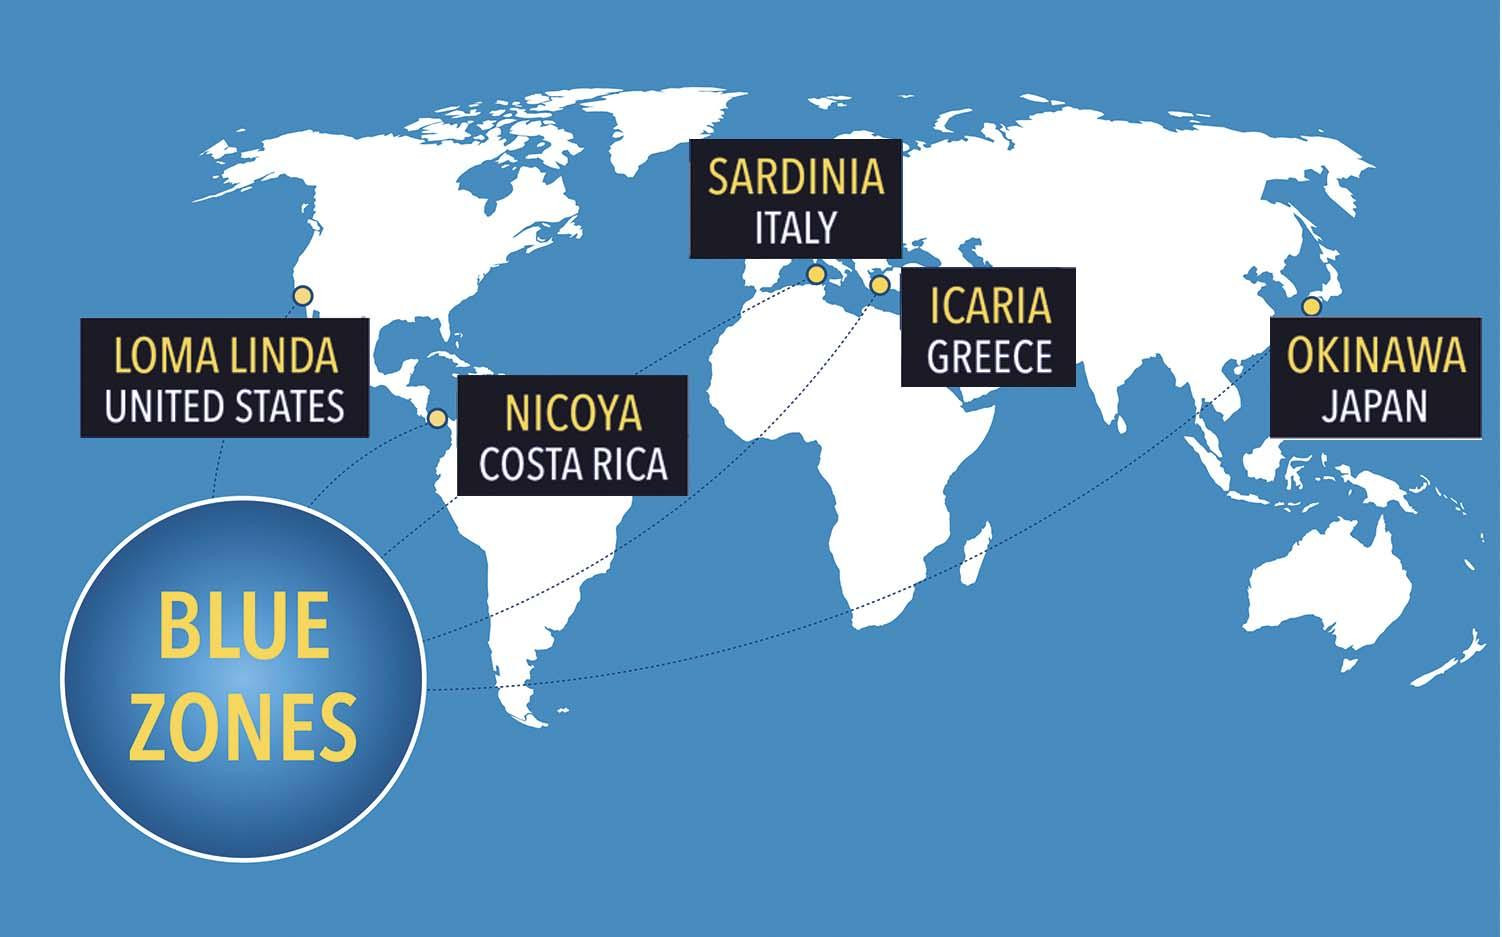

Source: Harvard Health Publishing. (2025, September 1). Living in the Blue Zone. Harvard Medical School. https://www.health.harvard.edu/healthy-aging-and-longevity/living-in-the-blue-zone

#### 0 Context:

Blue Zones are regions where people live exceptionally long lives, often reaching 100 years of age or more. Although mortality data cannot directly identify healthy aging trajectories, they provide valuable insights into the demographic, socioeconomic, and geographic characteristics of individuals who achieve exceptional longevity.

Using mortality records from Brazil's Mortality Information System (SIM), this study examines the profile and spatial distribution of centenarians at the time of death. The findings may help identify regions with a high concentration of long-lived individuals and generate hypotheses about potential longevity hotspots or "Blue Zones" in Brazil.

####Research Question:

What are the demographic, socioeconomic, and geographic characteristics of individuals who die at 100 years of age or older in Brazil in 2023, and do their spatial patterns suggest the existence of potential longevity hotspots?

####General Objective:

To characterize the demographic, socioeconomic, and geographic profile of individuals who died at 100 years of age or older in Brazil in 2023 using mortality records from the Mortality Information System (SIM).

####Specific Objectives:

* To describe the demographic and socioeconomic characteristics of centenarians at the time of death, including sex, race/ethnicity, marital status, and education.
* To analyze the underlying causes of death among centenarians.
* To map the geographic distribution of centenarian deaths across Brazil.
* To compare the profile of centenarians across Brazilian regions and states.
* To identify areas with a high concentration of centenarian deaths and explore their potential as longevity hotspots.
* To generate hypotheses about contextual factors associated with exceptional longevity in Brazil.

####Data Collection:
Mortality data were extracted from the Brazilian Mortality Information System (SIM) using the microdatasus package for R. This package provides a streamlined interface for accessing, downloading, and preprocessing microdata from the Department of Informatics of the Unified Health System (DATASUS), supporting several Brazilian Health Information Systems. The extraction process involved downloading SIM records and selecting variables related to demographic characteristics, socioeconomic conditions, place of residence, place of occurrence, and underlying causes of death. Subsequently, the data were processed using the package’s built-in functions, which translate coded variables into human-readable formats and prepare the dataset for statistical analysis. The use of microdatasus enhances the reproducibility, transparency, and efficiency of health data analyses based on DATASUS microdata (Saldanha et al., 2019).

####Source:
Saldanha RF, Bastos RR, Barcellos C. Microdatasus: package for downloading and preprocessing microdata from the Brazilian Health Informatics Department (DATASUS). Cad Saúde Pública. 2019;35(9):e00032419. https://doi.org/10.1590/0102-311X00032419

### 1 Import packages



In [ ]:
install.packages("remotes") # Allows installation of packages directly from GitHub
remotes::install_github("rfsaldanha/microdatasus") # Installs the microdatasus package from GitHub
install.packages("dplyr") # Data manipulation and cleaning
install.packages("writexl") # Export data frames to Excel (.xlsx) files

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




read.dbc  (NA    -> 52e0b15e7...) [GitHub]
withr     (3.0.2 -> 3.0.3       ) [CRAN]
bitops    (NA    -> 1.0-9       ) [CRAN]
zip       (2.3.3 -> 3.0.0       ) [CRAN]
RCurl     (NA    -> 1.98-1.19   ) [CRAN]
checkmate (NA    -> 2.3.4       ) [CRAN]


── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmphIQjCL/remotes6683dd73206/danicat-read.dbc-52e0b15/DESCRIPTION’ ... OK
* preparing ‘read.dbc’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘read.dbc_1.2.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing 5 packages: withr, bitops, zip, RCurl, checkmate

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Skipping install of 'read.dbc' from a github remote, the SHA1 (52e0b15e) has not changed since last install.
  Use `force = TRUE` to force installation



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmphIQjCL/remotes66831943884/rfsaldanha-microdatasus-b48e7cd/DESCRIPTION’ ... OK
* preparing ‘microdatasus’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Removed empty directory ‘microdatasus/vignettes’
* building ‘microdatasus_2.5.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



 ### 2 Load packages

In [ ]:
library(microdatasus) # Download and process DATASUS microdata
library(dplyr) # Data wrangling: filtering, selecting, grouping, and summarizing
library(writexl) # Export results to Excel files


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




### 3 Define parameters (UFs and variables)

In [ ]:
# Vector containing all the Brazilian states (UFs)
ufs <- c("AC","AL","AP","AM","BA","CE","DF","ES","GO",
             "MA","MT","MS","MG","PA","PB","PR","PE","PI",
             "RJ","RN","RS","RO","RR","SC","SP","SE","TO")

# Vector containing the variables to be extracted from the DATASUS mortality database (SIM).
selected_vars <- c(
  "DTOBITO", "IDADE", "SEXO", "RACACOR", "ESTCIV", "ESC",
  "CODMUNRES", "LOCOCOR", "CODMUNOCOR", "PESO",
  "CAUSABAS", "CIRCOBITO", "ACIDTRAB"
)

# Quality Check
cat("Number of UFs:", length(ufs), "\n") # total number of states included
cat("Number of variables:", length(selected_vars), "\n") # total number of selected variables

Number of UFs: 27 
Number of variables: 13 


### 4 Download raw data from DATASUS

In [ ]:
# Download mortality records from SIM for the specified year, states, and variables.
raw_data <- fetch_datasus( #Function for downloading raw DATASUS microdata.
  year_start = 2023,
  year_end = 2023,
  uf = ufs,
  information_system = "SIM-DO",
  vars = selected_vars
)

# Quality Check
cat("Rows:", nrow(raw_data), "| Columns:", ncol(raw_data), "\n") # number of records (rows) and variables (columns) retrieved
print(names(raw_data)) # names of all variables downloaded

ℹ Your local Internet connection seems to be ok.

ℹ DataSUS FTP server seems to be up and reachable.

ℹ Starting download...



Rows: 1465610 | Columns: 13 
 [1] "DTOBITO"    "IDADE"      "SEXO"       "RACACOR"    "ESTCIV"    
 [6] "ESC"        "CODMUNRES"  "LOCOCOR"    "CODMUNOCOR" "PESO"      
[11] "CAUSABAS"   "CIRCOBITO"  "ACIDTRAB"  


### 5 Filter Individuals Aged Over 100 Years

In [ ]:
# Raw IDADE encoding: 1st digit = unit (4 = years, 5 = 100+ years) remaining digits =
filtered_data <- raw_data %>%
  filter(
    !is.na(IDADE), # Exclude records with missing age information
    substr(as.character(IDADE), 1, 1) == "5" # Extracts the first digit and checks whether it is "5", the category used in SIM to represent centenarians (≥100 years).
  )

# Quality Check
cat("Rows before filter:", nrow(raw_data), "| Columns:", ncol(raw_data), "\n") # Number of records before filtering
cat("Rows after filter:", nrow(filtered_data), "| Columns:", ncol(raw_data), "\n") # Number of records remaining after filtering
print(sort(unique(filtered_data$IDADE))) # all unique age codes retained to verify that only centenarians were selected

Rows before filter: 1465610 | Columns: 13 
Rows after filter: 12149 | Columns: 13 
 [1] "500" "501" "502" "503" "504" "505" "506" "507" "508" "509" "510" "511"
[13] "512" "513" "514" "515" "516" "517" "518" "519" "520" "521" "523"


### 6 Process and Translate SIM Variables

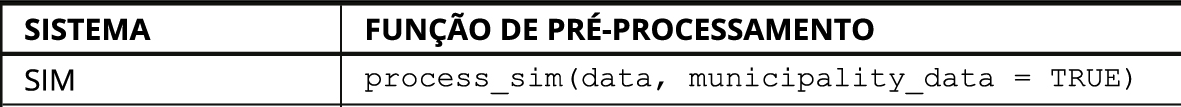

Source: Adapted from Saldanha et al., 2019 https://doi.org/10.1590/0102-311X00032419

In [ ]:
# The process_sim function converts the original DATASUS codes into readable categories, and also formats dates and labels to making the dataset easier to understand and analyse.
data <- process_sim(filtered_data)

# Quality Check
cat("Rows:", nrow(data), "| Columns:", ncol(data), "\n") # number of records after processing
print(names(data)) # variable names in the processed dataset

Rows: 12149 | Columns: 26 
 [1] "DTOBITO"      "IDADE"        "SEXO"         "RACACOR"      "ESTCIV"      
 [6] "ESC"          "CODMUNRES"    "LOCOCOR"      "CODMUNOCOR"   "PESO"        
[11] "CAUSABAS"     "CIRCOBITO"    "ACIDTRAB"     "IDADEminutos" "IDADEhoras"  
[16] "IDADEdias"    "IDADEmeses"   "IDADEanos"    "munResStatus" "munResTipo"  
[21] "munResNome"   "munResUf"     "munResLat"    "munResLon"    "munResAlt"   
[26] "munResArea"  


### 7 Convert to dataframe and explore the data

In [ ]:
df <- as.data.frame(data)
head(df)

,DTOBITO,IDADE,SEXO,RACACOR,ESTCIV,ESC,CODMUNRES,LOCOCOR,CODMUNOCOR,PESO,⋯,IDADEmeses,IDADEanos,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2023-01-06,500,Masculino,Branca,Viúvo,4 a 7 anos,120005,Hospital,120010,NA,⋯,NA,100,ATIVO,MUNIC,Assis Brasil,Acre,-10.94287,-69.56346,235,4974.176
2,2023-01-09,505,Masculino,Branca,Viúvo,4 a 7 anos,120040,Domicílio,120040,NA,⋯,NA,105,ATIVO,MUNIC,Rio Branco,Acre,-9.9783,-67.81053,138,8835.541
3,2023-01-10,508,Feminino,Branca,Viúvo,Nenhuma,120033,Domicílio,120033,NA,⋯,NA,108,ATIVO,MUNIC,Mâncio Lima,Acre,-7.59322,-72.9165,187,5453.005
4,2023-01-16,500,Masculino,Parda,Viúvo,Nenhuma,120040,Domicílio,120040,NA,⋯,NA,100,ATIVO,MUNIC,Rio Branco,Acre,-9.9783,-67.81053,138,8835.541
5,2023-01-30,501,Feminino,Parda,Solteiro,4 a 7 anos,120020,Domicílio,120020,NA,⋯,NA,101,ATIVO,MUNIC,Cruzeiro do Sul,Acre,-7.63069,-72.67253,183,8779.438
6,2023-02-07,507,Feminino,Parda,Viúvo,Nenhuma,120060,Hospital,120060,NA,⋯,NA,107,ATIVO,MUNIC,Tarauacá,Acre,-8.15567,-70.7555,172,20171.053


In [ ]:
str(df)

'data.frame':	12149 obs. of  26 variables:
 $ DTOBITO     : chr  "2023-01-06" "2023-01-09" "2023-01-10" "2023-01-16" ...
 $ IDADE       : chr  "500" "505" "508" "500" ...
 $ SEXO        : chr  "Masculino" "Masculino" "Feminino" "Masculino" ...
 $ RACACOR     : chr  "Branca" "Branca" "Branca" "Parda" ...
 $ ESTCIV      : chr  "Viúvo" "Viúvo" "Viúvo" "Viúvo" ...
 $ ESC         : chr  "4 a 7 anos" "4 a 7 anos" "Nenhuma" "Nenhuma" ...
 $ CODMUNRES   : chr  "120005" "120040" "120033" "120040" ...
 $ LOCOCOR     : chr  "Hospital" "Domicílio" "Domicílio" "Domicílio" ...
 $ CODMUNOCOR  : chr  "120010" "120040" "120033" "120040" ...
 $ PESO        : chr  NA NA NA NA ...
 $ CAUSABAS    : chr  "A91" "C449" "R960" "G309" ...
 $ CIRCOBITO   : chr  NA NA NA NA ...
 $ ACIDTRAB    : chr  NA NA NA NA ...
 $ IDADEminutos: chr  NA NA NA NA ...
 $ IDADEhoras  : chr  NA NA NA NA ...
 $ IDADEdias   : chr  NA NA NA NA ...
 $ IDADEmeses  : chr  NA NA NA NA ...
 $ IDADEanos   : chr  "100" "105" "108" "100" ...

In [ ]:
print(colSums(is.na(df)))

     DTOBITO        IDADE         SEXO      RACACOR       ESTCIV          ESC 
           0            0            1          198          753         1653 
   CODMUNRES      LOCOCOR   CODMUNOCOR         PESO     CAUSABAS    CIRCOBITO 
           0            7            0        12149            0        11898 
    ACIDTRAB IDADEminutos   IDADEhoras    IDADEdias   IDADEmeses    IDADEanos 
       12001        12149        12149        12149        12149            0 
munResStatus   munResTipo   munResNome     munResUf    munResLat    munResLon 
           0            0            0            0            4            4 
   munResAlt   munResArea 
           4            4 


In [ ]:
summary(df)

      DTOBITO            IDADE              SEXO            RACACOR     
 Length   :12149   Length   :12149   Length   :12149   Length   :12149  
 N.unique :  365   N.unique :   23   N.unique :    2   N.unique :    5  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:   10   Min.nchar:    3   Min.nchar:    8   Min.nchar:    5  
 Max.nchar:   10   Max.nchar:    3   Max.nchar:    9   Max.nchar:    8  
                                     NAs      :    1   NAs      :  198  
       ESTCIV             ESC            CODMUNRES          LOCOCOR     
 Length   :12149   Length   :12149   Length   :12149   Length   :12149  
 N.unique :    5   N.unique :    5   N.unique : 2954   N.unique :    6  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Min.nchar:    5   Min.nchar:    7   Min.nchar:    6   Min.nchar:    1  
 Max.nchar:   22   Max.nchar:   15   Max.nchar:    6   Max.nchar:   30  
 NAs      :  753   NAs      : 1653                 

### 8 Export to Excel and download

In [ ]:
output_file <- "/content/sim_100plus_brazil_2023.xlsx" # Define the output file path and name

write_xlsx(df, output_file) # Export the dataframe 'df' to an Excel file

# Quality Check
if (file.exists(output_file)) { # Check whether the Excel file was successfully created
  cat("File created successfully:", output_file, "\n") # If the file exists, print a success message with the file path
  cat("Rows exported:", nrow(df), "\n") # Print the number of rows exported
} else {
  cat("ERROR: file was not created.\n")
}

File created successfully: /content/sim_100plus_brazil_2023.xlsx 
Rows exported: 12149 
